# A/B Test

This is a study project created to practice and demonstrate A/B testing analysis.

## Overview

This project uses an open dataset from Kaggle:  
https://www.kaggle.com/datasets/zahrazolghadr/ab-test-cookie-cats/data

The dataset contains results of an A/B test that has already been completed.  
Because of that, some of the experiment design steps (such as baseline estimation and experiment duration) are reconstructed hypothetically for learning purposes.

## Dataset context

The dataset contains results of an A/B test for the mobile game Cookie Cats.  
The experiment investigates whether moving the first in-game gate from level 30 to level 40 affects player engagement.

When installing the game, players were randomly assigned to one of two groups:

- gate_30 (control group) – the gate appears at level 30  
- gate_40 (test group) – the gate appears at level 40

The dataset includes the following variables:

- `userid` – unique player identifier  
- `version` – experiment group (gate_30 or gate_40)  
- `sum_gamerounds` – number of game rounds played during the first 14 days after installation  
- `retention_1` – whether the player returned after 1 day  
- `retention_7` – whether the player returned after 7 days

## Steps

0. Data validation
1. Setting a hypothesis
2. Getting baseline numbers for metrics
3. Minimum Detectable Effect (MDE)
4. Power Analysis
5. Estimate duration of the experiment
6. Results analysis

## Data validation

The dataset is imported from a CSV file and basic validation checks are performed:

- missing values
- incorrect values
- duplicate users

Most players have between 1 and 2961 game rounds.  
However, one user (id = 6390605) has 49,854 rounds recorded.

This value is an extreme outlier that could significantly distort the average.  
It may be caused by a logging error or abnormal behavior.  
To prevent it from affecting the analysis, this observation is removed from the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy.stats as stats

In [2]:
user_data = pd.read_csv('cookie_cats.txt')
display(user_data.head())
display(user_data.info())
print('Uniquie users: {}'.format(user_data['userid'].nunique()))
print('Uniquie versions: {}'.format(user_data['version'].unique()))

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB


None

Uniquie users: 90189
Uniquie versions: <StringArray>
['gate_30', 'gate_40']
Length: 2, dtype: str


<Axes: ylabel='Frequency'>

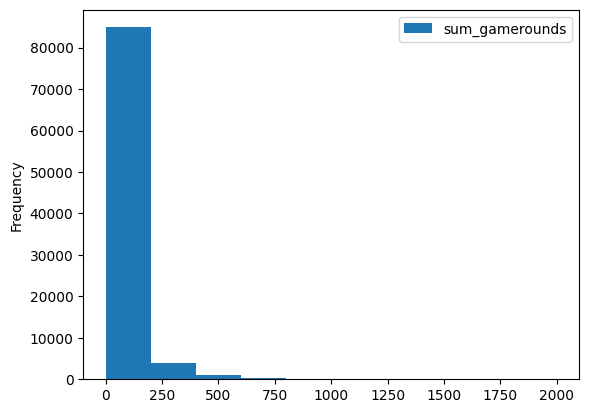

In [3]:
user_data.plot.hist(column='sum_gamerounds', range=(0, 2000))

In [4]:
user_data[user_data['sum_gamerounds'] > 2000]

,userid,version,sum_gamerounds,retention_1,retention_7
6536,725080,gate_40,2015,True,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
36933,4090246,gate_40,2124,True,True
43671,4832608,gate_30,2438,True,True
46344,5133952,gate_30,2251,True,True
48188,5346171,gate_40,2294,True,True
57702,6390605,gate_30,49854,False,True
87007,9640085,gate_30,2156,True,True
88328,9791599,gate_40,2063,True,True


In [5]:
# removing suspicious user
user_data = user_data[user_data['userid'] != 6390605]

In [6]:
user_data.groupby(by='version')['userid'].count()

version
gate_30    44699
gate_40    45489
Name: userid, dtype: int64

## Hypothesis

### Experiment goal

Evaluate whether moving the first gate from level 30 to level 40 increases player engagement.

### Metric

Primary metric:
Average number of game rounds played in the first 14 days after install (`sum_gamerounds`).

H₀: $E({sum\_gamerounds}_{gate40}) = E({sum\_gamerounds}_{gate30})$

H₁: $E({sum\_gamerounds}_{gate40}) <> E({sum\_gamerounds}_{gate30})$

## Getting baseline numbers for metrics

Since the dataset does not contain pre-experiment metrics, baseline values must be estimated.

To illustrate the experiment design process (MDE and power analysis), a small sample from the control group is used as a proxy for pre-experiment behavior.

Assuming that user IDs increase over time, the **first 500 users from the control group** are used to estimate baseline metrics.  
This approximates observing the metric before the experiment started.

These baseline estimates are used only for experiment design calculations and are excluded from the final analysis.

Moving on, I'll consider the metrics before A/B test start were following:

| Number of game rounds played by users | |
| --- | --- |
| mean | 55.95 |
|std | 129.27 |

The distribution of game rounds is highly right-skewed, with a small number of players playing significantly more rounds than average. This pattern is typical for mobile games, where a minority of highly engaged players contribute a large share of activity.
The standard deviation is significantly larger than the median, indicating a highly skewed distribution with a long right tail.

In [7]:
fisrt_control_500 = user_data[user_data['version'] == 'gate_30'].sort_values(by='userid')[:500]
print(fisrt_control_500[['sum_gamerounds', 'retention_1', 'retention_7']].mean())
print('Sample std: {}'.format(fisrt_control_500['sum_gamerounds'].std()))

sum_gamerounds    55.952
retention_1        0.430
retention_7        0.204
dtype: float64
Sample std: 129.27103192668795


## Minimum Detectable Effect (MDE)

The Minimum Detectable Effect (MDE) represents the smallest change in a metric that the experiment should be able to detect with sufficient statistical power.

In practice, MDE is usually determined based on:

- expected business impact
- results of previous experiments
- experiment duration and available traffic

Since historical experiment data is not available for this dataset, a practical assumption is used.

For engagement metrics in mobile games, changes smaller than 5–10% are often considered too small to have meaningful product impact.  
Therefore, this analysis assumes a 10% relative change as the minimum detectable effect.

Given the baseline mean of 55.95 rounds, the MDE corresponds to approximately 5.6 rounds per user.

$MDE = 0.1 × 55.95 ≈ 5.6\ rounds$

### Note
Since I used the data of 500 control users to build baseline, and $Enrollment\ ratio = 1$ in the A/B test, I'm going to remove first 500 test and control users from further analysis (total of 1000, leaving 89 188 for further analysis).

In [8]:
fisrt_test_500 = user_data[user_data['version'] == 'gate_40'].sort_values(by='userid')[:500]
rest_user_data = user_data.drop(fisrt_control_500.index, axis=0, inplace=False) \
                            .drop(fisrt_test_500.index, axis=0, inplace=False)
rest_user_data.info()

<class 'pandas.DataFrame'>
Index: 89188 entries, 992 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          89188 non-null  int64
 1   version         89188 non-null  str  
 2   sum_gamerounds  89188 non-null  int64
 3   retention_1     89188 non-null  bool 
 4   retention_7     89188 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.9 MB


## Power Analysis

To estimate the required sample size, the following parameters were used in an [online power analysis calculator](https://www.omnicalculator.com/statistics/power-analysis):

| Parameter | Value |
| --- | --- |
| Baseline mean | 55.95 |
| Standard deviation | 129.27 |
| Minimum detectable effect | 5.6 rounds (10%) |
| Alpha | 0.05 |
| Power | 0.80 |

Based on these parameters, the required sample size is approximately 8,371 users per group, or 16,742 users in total.

The relatively large sample size is mainly caused by the high variance of the metric.  
The standard deviation is more than twice the mean, indicating a highly skewed distribution with a long right tail, which is common for engagement metrics in mobile games.

Since the dataset contains 89,988 users in total, the available sample size is more than sufficient to detect the specified effect.

## Estimate duration of the experiment

The required sample size for the experiment is approximately: 16,742 users.

To estimate experiment duration, the number of daily installs must be considered.  
Since the dataset does not provide this information, several traffic scenarios are used.

| Daily installs | Estimated duration |
| --- | --- |
| 1,000 | 17 days |
| 5,000 | 4 days |
| 10,000 | 2 day |

In practice, experiment duration should also account for weekly seasonality, marketing campaigns, and player behavior differences between weekdays and weekends.

For this reason, experiments are often run for at least one full week, even if the required sample size could theoretically be reached faster.

## Results analysis

### Group balance

First, the number of users in each group is compared to verify proper randomization.

The groups contain approximately the same number of users, indicating that the experiment was balanced.

version
gate_30    44199
gate_40    44989
Name: userid, dtype: int64

<Axes: xlabel='version'>

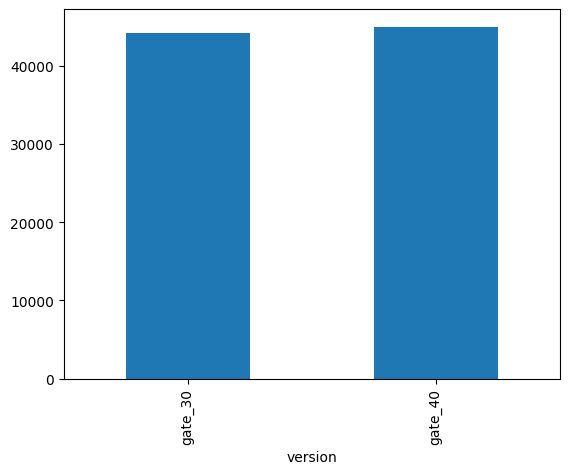

In [9]:
display(rest_user_data.groupby('version')['userid'].count())
rest_user_data.groupby('version')['userid'].count().plot.bar()

### Distribution analysis

The distribution of `sum_gamerounds` is highly right-skewed with a long tail.

This pattern is common for engagement metrics in mobile games, where most players play relatively few rounds while a small number of highly engaged users play significantly more.

Because of this skewed distribution, statistical tests that are robust to non-normal data are preferred.

(array([4.366e+04, 1.063e+03, 1.830e+02, 4.900e+01, 1.900e+01, 9.000e+00,
        3.000e+00, 2.000e+00, 1.000e+00, 0.000e+00]),
 array([   0.,  300.,  600.,  900., 1200., 1500., 1800., 2100., 2400.,
        2700., 3000.]),
 <BarContainer object of 10 artists>)

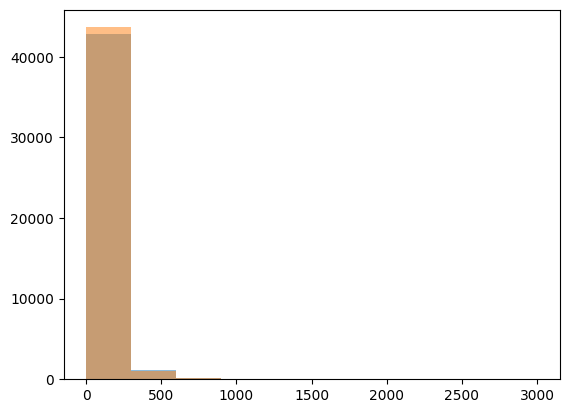

In [10]:
plt.hist(rest_user_data[rest_user_data['version'] == 'gate_30']['sum_gamerounds'], alpha=0.5, range=(0,3000))
plt.hist(rest_user_data[rest_user_data['version'] == 'gate_40']['sum_gamerounds'], alpha=0.5, range=(0,3000))

### Descriptive statistics

In [11]:
test_stats = rest_user_data.groupby('version')['sum_gamerounds'].agg(['mean', 'median', 'std', 'count'])
test_stats

,mean,median,std,count
version,,,,
gate_30,51.289961,17.0,101.708760,44199
gate_40,51.421970,16.0,103.594105,44989


### Confidence Interval

Confidence interval for the mean difference includes 0, so it shows that there probably are no difference between test and control groups.

In [12]:
mean_diff = test_stats.loc['gate_30', 'mean'] - test_stats.loc['gate_40', 'mean']
std_control = test_stats.loc['gate_30', 'std']
std_test = test_stats.loc['gate_40', 'std']
n_control = test_stats.loc['gate_30', 'count']
n_test = test_stats.loc['gate_40', 'count']

se = np.sqrt(
    std_control**2 / n_control +
    std_test**2 / n_test
)

ci_low = mean_diff - 1.96 * se
ci_high = mean_diff + 1.96 * se
print('CI for this test is [{:.2f}, {:.2f}]'.format(ci_low, ci_high))

CI for this test is [-1.48, 1.22]


### Hypothesis testing

Welch’s t-test is used to compare the mean number of game rounds between the two groups.

This test is appropriate because it does not require equal variances and is robust when sample sizes are large.

The test returns p-value = 0.84, which means the null hypothesis cannot be rejected.

Therefore, there is no statistically significant difference between the two groups in terms of the average number of game rounds played.

In [13]:
control_group = rest_user_data[rest_user_data['version'] == 'gate_30']['sum_gamerounds']
test_group = rest_user_data[rest_user_data['version'] == 'gate_40']['sum_gamerounds']
print(stats.ttest_ind(control_group, test_group, equal_var = False))

TtestResult(statistic=np.float64(-0.19202602350265885), pvalue=np.float64(0.8477222581185183), df=np.float64(89185.96221345106))


### Practical significance

The observed difference between the groups is 0.13 rounds, which corresponds to a relative change of approximately 0.25%.

Even if such a difference were statistically significant, it would be far too small to have meaningful product impact.

Therefore, the change does not provide practical value.

## Conclusion

### Experiment results show

- the average number of game rounds is almost identical in both groups
- the observed difference is approximately 0.25%
- this is far below the predefined minimum detectable effect of 10%

### Final conclusion

Moving the gate from level 30 to level 40 does not increase player engagement when measured by the number of game rounds played.